<a href="https://colab.research.google.com/github/sureshsaripalle2004/Task3-Linear-Regression/blob/main/Task3_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Task 3: Linear Regression

Objective: Implement and understand simple & multiple linear regression.

Tools: Scikit-learn, Pandas, Matplotlib

Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Upload dataset

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Housing.csv to Housing.csv


Load dataset

In [3]:
data = pd.read_csv("Housing.csv")
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


Handle categorical data

In [5]:
data.replace({'yes': 1, 'no': 0}, inplace=True)

/tmp/ipykernel_629/3138928139.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data.replace({'yes': 1, 'no': 0}, inplace=True)


In [6]:
data = pd.get_dummies(data, columns=['furnishingstatus'], drop_first=True)

Select features

Simple Linear Regression

In [20]:
X = data[['area']]   # one feature
y = data['price']

Train-test split

In [21]:


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Train model

In [22]:


model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

Prediction

In [23]:
y_pred = model.predict(X_test)

Evaluation

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 1474748.1337969352
MSE: 3675286604768.185
R2 Score: 0.27287851871974644


Plot

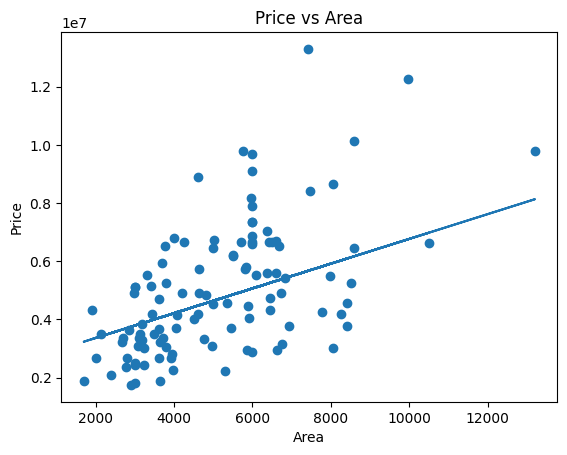

In [25]:
import matplotlib.pyplot as plt

plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred)
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Price vs Area")
plt.show()

Coefficients

In [26]:
print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_)

Intercept: 2512254.2639593435
Coefficient: [425.72984194]


MULTIPLE LINEAR REGRESSION

In [28]:
X = data.drop('price', axis=1)
y = data['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 970043.4039201637
MSE: 1754318687330.6633
R2 Score: 0.6529242642153185


Plot for Multiple Regression

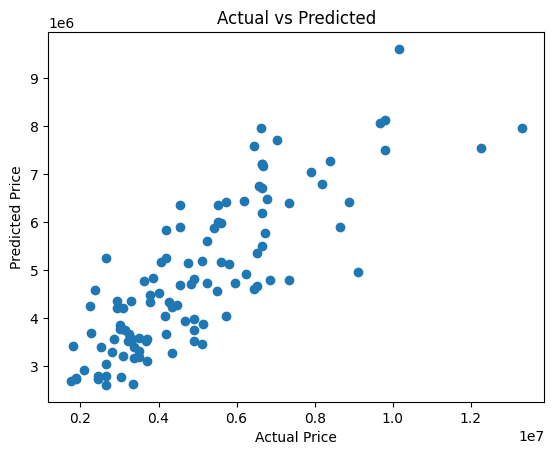

In [29]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()